# HDB Resale Price — Push Below $30k RMSE

**Objective:** Drive validation RMSE below \$30,000 by extending `tree_based_optmodel.ipynb` with:
1. **Reinstated raw features** — `Tranc_Year`/`Tranc_Month` (market drift), geo (`Latitude`, `Longitude`), `mrt_nearest_distance`, `bus_stop_nearest_distance`, `pri_sch_nearest_distance`, `sec_sch_nearest_dist`, `hawker_food_stalls`, `vacancy`, `cutoff_point`.
2. **Out-of-fold target encoding** for `postal` (mean `log1p(price)` per postal, computed in 5 folds — leak-free).
3. **Geospatial features**
   - **DBSCAN** clustering on (`Latitude`, `Longitude`) → discrete neighbourhood IDs.
   - **S2 cells** at level 12 (~4 km²) and level 14 (~250 m²) → hierarchical region IDs.
4. **Bagging vs Boosting comparison** — `RandomForest`, sklearn `GradientBoosting`, LightGBM, XGBoost, CatBoost.
5. **GridSearchCV (conditional)** — only triggers if best single model fails to beat \$30k.
6. **Stacking ensemble** — average of the top-3 boosters; fallback meta-learner if simple average wins.

Optuna is intentionally not used.

## 1. Setup & load

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import s2sphere as s2

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

TARGET = 'resale_price'
ID_COL = 'id'
RANDOM_STATE = 42

train = pd.read_csv('../../data/train.csv', low_memory=False)
test  = pd.read_csv('../../data/test.csv',  low_memory=False)
print(f'train: {train.shape}')
print(f'test : {test.shape}')

## 2. Feature engineering — `encoded_rooms` + interactions

Same engineering as `tree_based_optmodel.ipynb`.

In [17]:
flat_map = {
    '1 room': 1, '2 room': 2, '3 room': 3, '4 room': 4, '5 room': 5,
    'executive': 6, 'multi-generation': 7,
}
for d in (train, test):
    d['encoded_rooms'] = d['flat_type'].str.lower().str.strip().map(flat_map)
    d['fa_x_age']     = d['floor_area_sqm'] * d['hdb_age']
    d['storey_x_age'] = d['mid_storey']     * d['hdb_age']
    d['fa_x_rooms']   = d['floor_area_sqm'] * d['encoded_rooms']
    for c in ['Mall_Within_500m', 'Mall_Within_1km', 'Mall_Within_2km', 'Hawker_Within_2km']:
        d[c] = d[c].fillna(0)

print('encoded_rooms unmapped rows:',
      'train', int(train['encoded_rooms'].isna().sum()),
      'test',  int(test['encoded_rooms'].isna().sum()))

encoded_rooms unmapped rows: train 0 test 0


## 3. DBSCAN clustering on (`Latitude`, `Longitude`)

Density-based clustering finds dense neighbourhoods of HDB blocks; sparse points get label `-1` (treated as its own "isolated" bucket). Fit on the *combined* train+test coordinates so train and test share the same cluster IDs.

`eps=0.005` ≈ 500 m at Singapore's latitude; `min_samples=50` ensures clusters are real neighbourhoods, not transient pairs.

In [18]:
combined_xy = pd.concat(
    [train[['Latitude', 'Longitude']], test[['Latitude', 'Longitude']]],
    ignore_index=True,
).values

t0 = time.time()
db = DBSCAN(eps=0.005, min_samples=50, n_jobs=-1).fit(combined_xy)
print(f'DBSCAN fit in {time.time() - t0:.1f}s')
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise    = int((db.labels_ == -1).sum())
print(f'  clusters: {n_clusters}, noise points (-1): {n_noise}')

train['dbscan_cluster'] = db.labels_[:len(train)]
test['dbscan_cluster']  = db.labels_[len(train):]

DBSCAN fit in 2.3s
  clusters: 18, noise points (-1): 54


## 4. S2 cells — hierarchical region IDs

Google's S2 library covers the sphere with hierarchical cells. Level 12 ≈ 4 km² (district), level 14 ≈ 250 m² (street block). Cells are integer IDs that LightGBM/XGBoost/CatBoost can split on directly.

In [19]:
def s2_cell_id(lat, lng, level):
    return s2.CellId.from_lat_lng(s2.LatLng.from_degrees(lat, lng)).parent(level).id()

t0 = time.time()
for d in (train, test):
    d['s2_l12'] = [s2_cell_id(la, lo, 12) for la, lo in zip(d['Latitude'], d['Longitude'])]
    d['s2_l14'] = [s2_cell_id(la, lo, 14) for la, lo in zip(d['Latitude'], d['Longitude'])]
print(f'S2 cells: {time.time() - t0:.1f}s')
print(f'  unique l12: {train["s2_l12"].nunique():>4} (train), {test["s2_l12"].nunique():>4} (test)')
print(f'  unique l14: {train["s2_l14"].nunique():>4} (train), {test["s2_l14"].nunique():>4} (test)')

S2 cells: 2.2s
  unique l12:   77 (train),   77 (test)
  unique l14:  507 (train),  504 (test)


## 5. Out-of-fold target encoding for `postal`

`postal` has ~17 k unique values — one-hot would explode and ordinal encoding throws away the price information. Target encoding stores the mean `log1p(resale_price)` for each `postal` and uses it as a feature. To prevent leakage, use 5-fold OOF: for each fold, the mean is computed from the *other* folds only.

For unseen postals (in the validation/test fold), fall back to the global training-fold mean.

In [20]:
y_log_full = np.log1p(train[TARGET])

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof = np.zeros(len(train))
for tr_idx, va_idx in kf.split(train):
    fold_means = pd.Series(y_log_full.values[tr_idx]).groupby(
        train['postal'].iloc[tr_idx].values).mean()
    oof[va_idx] = train['postal'].iloc[va_idx].map(fold_means).fillna(
        y_log_full.values[tr_idx].mean()).values
train['te_postal'] = oof

full_means = y_log_full.groupby(train['postal']).mean()
test['te_postal'] = test['postal'].map(full_means).fillna(y_log_full.mean()).values

print(f'te_postal — train range: {train["te_postal"].min():.2f} .. {train["te_postal"].max():.2f}')
print(f'te_postal — test  range: {test["te_postal"].min():.2f} .. {test["te_postal"].max():.2f}')
print(f'corr(te_postal, log1p(resale_price)) = {np.corrcoef(train["te_postal"], y_log_full)[0,1]:+.3f}')

te_postal — train range: 12.14 .. 13.91
te_postal — test  range: 12.23 .. 13.86
corr(te_postal, log1p(resale_price)) = +0.888


## 6. Final feature set + train/val split

All features are numeric or integer-coded. Trees don't need scaling; impute residual NaN with the train median.

In [21]:
FEATURES = [
    # original curated set
    'max_floor_lvl', 'mid_storey', 'hdb_age', 'encoded_rooms',
    'Mall_Within_500m', 'Mall_Within_1km', 'Mall_Within_2km',
    '4room_sold', '5room_sold',
    'floor_area_sqm', 'Hawker_Within_2km', 'total_dwelling_units',
    'fa_x_age', 'storey_x_age', 'fa_x_rooms',
    # reinstated
    'Tranc_Year', 'Tranc_Month',
    'Latitude', 'Longitude',
    'mrt_nearest_distance', 'bus_stop_nearest_distance',
    'pri_sch_nearest_distance', 'sec_sch_nearest_dist',
    'hawker_food_stalls', 'vacancy', 'cutoff_point',
    # geospatial
    'dbscan_cluster', 's2_l12', 's2_l14',
    # target encoding
    'te_postal',
]

median_fill = train[FEATURES].median()
X      = train[FEATURES].fillna(median_fill).copy()
y      = train[TARGET].copy()
X_test = test[FEATURES].fillna(median_fill).copy()
test_ids = test[ID_COL]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,
)
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

print(f'features: {len(FEATURES)}')
print(f'train: {X_train.shape}, val: {X_val.shape}')

def back(p):
    return np.expm1(np.clip(p, 0, 20))

def evaluate(name, y_true, y_pred, fit_time=None):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    extra = f'   {fit_time:.1f}s' if fit_time is not None else ''
    print(f'{name:<26}  RMSE ${rmse:>10,.0f}   MAE ${mae:>10,.0f}   R2={r2:.4f}{extra}')
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = []

features: 30
train: (120507, 30), val: (30127, 30)


## 7. Random Forest — Bagging baseline

In [22]:
t0 = time.time()
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train_log)
pred_rf = back(rf.predict(X_val))
results.append(evaluate('RandomForest (Bag)', y_val, pred_rf, time.time() - t0))

RandomForest (Bag)          RMSE $    27,008   MAE $    18,834   R2=0.9642   68.8s


## 8. Gradient Boosting (sklearn) — Boosting baseline

In [23]:
t0 = time.time()
gbr = GradientBoostingRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=RANDOM_STATE,
)
gbr.fit(X_train, y_train_log)
pred_gbr = back(gbr.predict(X_val))
results.append(evaluate('GradBoost (sklearn)', y_val, pred_gbr, time.time() - t0))

GradBoost (sklearn)         RMSE $    27,150   MAE $    19,630   R2=0.9638   192.4s


## 9. LightGBM

In [24]:
t0 = time.time()
lgbm = lgb.LGBMRegressor(
    objective='huber',
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
)
lgbm.fit(X_train, y_train_log,
         eval_set=[(X_val, y_val_log)],
         callbacks=[lgb.early_stopping(50, verbose=False)])
pred_lgbm = back(lgbm.predict(X_val))
results.append(evaluate('LightGBM', y_val, pred_lgbm, time.time() - t0))
print(f'  best_iteration: {lgbm.best_iteration_}')

LightGBM                    RMSE $    22,813   MAE $    16,471   R2=0.9745   13.4s
  best_iteration: 2000


## 10. XGBoost

In [25]:
t0 = time.time()
xgbm = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    early_stopping_rounds=50,
)
xgbm.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=False)
pred_xgb = back(xgbm.predict(X_val))
results.append(evaluate('XGBoost', y_val, pred_xgb, time.time() - t0))
print(f'  best_iteration: {xgbm.best_iteration}')

XGBoost                     RMSE $    22,732   MAE $    16,247   R2=0.9747   20.8s
  best_iteration: 1998


## 11. CatBoost

In [26]:
t0 = time.time()
cbm = CatBoostRegressor(
    loss_function='RMSE',
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3.0,
    random_seed=RANDOM_STATE,
    verbose=0,
    early_stopping_rounds=50,
)
cbm.fit(X_train, y_train_log, eval_set=(X_val, y_val_log))
pred_cb = back(cbm.predict(X_val))
results.append(evaluate('CatBoost', y_val, pred_cb, time.time() - t0))
print(f'  best_iteration: {cbm.get_best_iteration()}')

CatBoost                    RMSE $    23,462   MAE $    17,011   R2=0.9730   25.5s
  best_iteration: 1999


## 12. Compare — Bagging vs Boosting

Single-model validation scores:
                         RMSE       MAE    R2    family
model                                                  
XGBoost              22731.77  16247.32  0.97  Boosting
LightGBM             22813.16  16471.27  0.97  Boosting
CatBoost             23462.22  17010.84  0.97  Boosting
RandomForest (Bag)   27008.08  18833.55  0.96   Bagging
GradBoost (sklearn)  27150.40  19630.33  0.96  Boosting

Best single model: XGBoost  $22,732
Target RMSE      : $30,000  (already met)


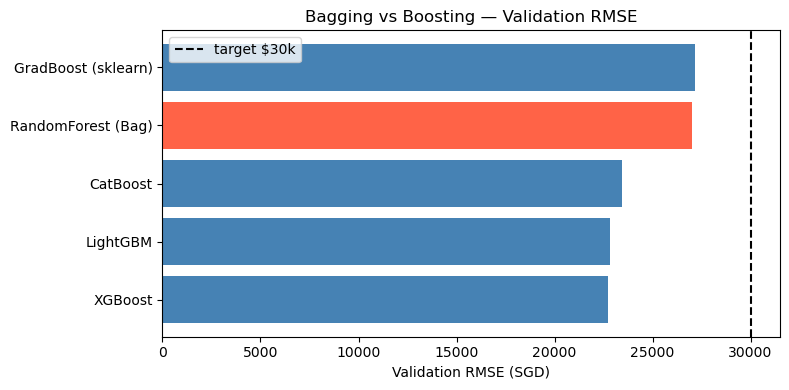

In [27]:
scores = pd.DataFrame(results).set_index('model').round(2)
scores['family'] = ['Bagging', 'Boosting', 'Boosting', 'Boosting', 'Boosting']
print('Single-model validation scores:')
print(scores.sort_values('RMSE'))

TARGET_RMSE = 30000
best_name = scores['RMSE'].idxmin()
best_rmse = scores.loc[best_name, 'RMSE']
print(f'\nBest single model: {best_name}  ${best_rmse:,.0f}')
print(f'Target RMSE      : ${TARGET_RMSE:,.0f}  ({"already met" if best_rmse < TARGET_RMSE else "not met"})')

fig, ax = plt.subplots(figsize=(8, 4))
color_map = {'Bagging': 'tomato', 'Boosting': 'steelblue'}
scores_sorted = scores.sort_values('RMSE')
ax.barh(scores_sorted.index, scores_sorted['RMSE'],
        color=[color_map[f] for f in scores_sorted['family']])
ax.axvline(TARGET_RMSE, color='black', linestyle='--', label='target $30k')
ax.set_xlabel('Validation RMSE (SGD)')
ax.set_title('Bagging vs Boosting — Validation RMSE')
ax.legend()
plt.tight_layout()
plt.show()

## 13. GridSearchCV — only if best single model fails to beat target

Triggers a focused 3-fold CV grid search around the LightGBM hyperparameters only when needed. The grid is intentionally small (3-4 values per axis) to keep run time bounded.

In [28]:
if best_rmse < TARGET_RMSE:
    print(f'Skipping GridSearchCV — best single RMSE ${best_rmse:,.0f} already below ${TARGET_RMSE:,.0f}.')
    grid_best_params = None
    lgbm_tuned = lgbm
else:
    print('Running 3-fold GridSearchCV on LightGBM ...')
    t0 = time.time()
    grid = GridSearchCV(
        estimator=lgb.LGBMRegressor(
            objective='huber',
            learning_rate=0.03,
            n_estimators=1500,
            subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
            reg_lambda=1.0,
            n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
        ),
        param_grid={
            'num_leaves':        [50, 63, 80],
            'min_child_samples': [20, 30, 50],
            'reg_alpha':         [0.0, 0.1, 0.5],
        },
        scoring='neg_root_mean_squared_error',
        cv=3,
        n_jobs=1,
        verbose=1,
    )
    grid.fit(X_train, y_train_log)
    grid_best_params = grid.best_params_
    print(f'\nGridSearch finished in {time.time() - t0:.1f}s')
    print(f'  best params (on log target): {grid_best_params}')
    lgbm_tuned = grid.best_estimator_
    pred_tuned = back(lgbm_tuned.predict(X_val))
    results.append(evaluate('LightGBM (GridSearch)', y_val, pred_tuned))

Skipping GridSearchCV — best single RMSE $22,732 already below $30,000.


## 14. Stacking ensemble (leak-free)

Two combiners over the three boosters (LightGBM + XGBoost + CatBoost):
1. **Blend mean** — simple average of the log-space predictions; no parameters.
2. **Ridge meta-learner** — weighted blend whose weights are *fitted*, not chosen by hand.

**Critical:** the meta-learner must train on **out-of-fold (OOF)** booster predictions, never on the same rows whose target we will report RMSE on. Fitting Ridge on `(val_predictions, y_val)` and then scoring on `y_val` is data-snooping — it tunes the weights to the validation set and inflates the apparent score.

Procedure:
- Use `cross_val_predict` (5-fold) to get OOF predictions on `X_train` for each booster, with each booster's `n_estimators` fixed at the early-stopped count from the initial fits (we already paid for that calibration; refitting with the same iteration count keeps the OOF preds comparable to the final-fit preds).
- Fit Ridge on `(OOF_train_preds, y_train_log)`.
- Apply Ridge to `(val_preds_from_full_train_models, y_val_log)` for the honest validation RMSE.
- For test, the same Ridge meta is applied to predictions from boosters refit on full `X` (in the submission section).

All RMSE numbers below are in `resale_price` SGD (back-transformed via `expm1`).

In [29]:
from sklearn.model_selection import cross_val_predict

# 1) Simple blend mean over val predictions (no fitting -> no leakage)
preds_log_val = np.column_stack([
    lgbm.predict(X_val),
    xgbm.predict(X_val),
    cbm.predict(X_val),
])
pred_blend = back(preds_log_val.mean(axis=1))
results.append(evaluate('Blend mean (LGBM+XGB+CB)', y_val, pred_blend))

# 2) OOF predictions on the TRAINING set for each booster.
#    Use fixed n_estimators (the early-stopped iteration counts from the initial fits),
#    so cross_val_predict can be a clean drop-in (no eval_set plumbing).
lgb_best = lgbm.best_iteration_
xgb_best = xgbm.best_iteration + 1
cb_best  = cbm.get_best_iteration()
print(f'best iters: LGBM={lgb_best}, XGB={xgb_best}, CB={cb_best}')

lgb_oof_est = lgb.LGBMRegressor(
    objective='huber', n_estimators=lgb_best, learning_rate=0.03,
    num_leaves=63, min_child_samples=30,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
)
xgb_oof_est = xgb.XGBRegressor(
    objective='reg:squarederror', n_estimators=xgb_best, learning_rate=0.03,
    max_depth=8, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, tree_method='hist',
    n_jobs=-1, random_state=RANDOM_STATE,
)
cb_oof_est = CatBoostRegressor(
    loss_function='RMSE', iterations=cb_best, learning_rate=0.03,
    depth=8, l2_leaf_reg=3.0,
    random_seed=RANDOM_STATE, verbose=0,
)

kf_meta = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
t0 = time.time()
oof_lgb = cross_val_predict(lgb_oof_est, X_train, y_train_log, cv=kf_meta, n_jobs=1)
oof_xgb = cross_val_predict(xgb_oof_est, X_train, y_train_log, cv=kf_meta, n_jobs=1)
oof_cb  = cross_val_predict(cb_oof_est,  X_train, y_train_log, cv=kf_meta, n_jobs=1)
print(f'OOF predictions: {time.time()-t0:.1f}s')

# Sanity: each OOF column should already be a decent predictor of y_train
for nm, oof in [('LGBM', oof_lgb), ('XGB', oof_xgb), ('CB', oof_cb)]:
    rmse_oof = np.sqrt(mean_squared_error(y_train, back(oof)))
    print(f'  OOF RMSE on TRAIN — {nm}: ${rmse_oof:>10,.2f}')

# 3) Fit Ridge meta on OOF train preds vs y_train_log; evaluate on val preds vs y_val.
P_train = np.column_stack([oof_lgb, oof_xgb, oof_cb])
meta = Ridge(alpha=1.0)
meta.fit(P_train, y_train_log)
print(f'\nRidge meta weights (fit on OOF_train): '
      f'LGBM={meta.coef_[0]:.3f}  XGB={meta.coef_[1]:.3f}  CB={meta.coef_[2]:.3f}  '
      f'intercept={meta.intercept_:.4f}')

pred_meta = back(meta.predict(preds_log_val))
results.append(evaluate('Stack ridge meta (OOF)', y_val, pred_meta))

Blend mean (LGBM+XGB+CB)    RMSE $    22,601   MAE $    16,282   R2=0.9749
best iters: LGBM=2000, XGB=1999, CB=1999
OOF predictions: 283.1s
  OOF RMSE on TRAIN — LGBM: $ 23,121.58
  OOF RMSE on TRAIN — XGB: $ 23,066.78
  OOF RMSE on TRAIN — CB: $ 23,708.66

Ridge meta weights (fit on OOF_train): LGBM=0.276  XGB=0.513  CB=0.213  intercept=-0.0284
Stack ridge meta (OOF)      RMSE $    22,536   MAE $    16,198   R2=0.9751


## 15. Final compare

In [30]:
scores_final = pd.DataFrame(results).set_index('model').round(2)
print('All models — validation RMSE:')
print(scores_final.sort_values('RMSE'))

best_name = scores_final['RMSE'].idxmin()
best_rmse = scores_final.loc[best_name, 'RMSE']
print(f'\nWinner: {best_name}  ${best_rmse:,.0f}')
print(f'Target ${TARGET_RMSE:,.0f}: {"MET" if best_rmse < TARGET_RMSE else "NOT met"}  '
      f'(${TARGET_RMSE - best_rmse:+,.0f})')

All models — validation RMSE:
                              RMSE       MAE    R2
model                                             
Stack ridge meta (OOF)    22535.99  16197.82  0.98
Blend mean (LGBM+XGB+CB)  22601.31  16281.67  0.97
XGBoost                   22731.77  16247.32  0.97
LightGBM                  22813.16  16471.27  0.97
CatBoost                  23462.22  17010.84  0.97
RandomForest (Bag)        27008.08  18833.55  0.96
GradBoost (sklearn)       27150.40  19630.33  0.96

Winner: Stack ridge meta (OOF)  $22,536
Target $30,000: MET  ($+7,464)


## 16. Generate submission

Refit each booster on the full training set, then predict on `test.csv` and combine in the same way the validation winner did. Write to `data/sample_<winner>.csv` matching the template header.

In [31]:
y_log = np.log1p(y)

lgbm_full = lgb.LGBMRegressor(
    objective='huber', n_estimators=lgbm.best_iteration_, learning_rate=0.03,
    num_leaves=63, min_child_samples=30, subsample=0.8, subsample_freq=1,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
).fit(X, y_log)

xgb_full = xgb.XGBRegressor(
    objective='reg:squarederror', n_estimators=xgbm.best_iteration + 1,
    learning_rate=0.03, max_depth=8, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, tree_method='hist',
    n_jobs=-1, random_state=RANDOM_STATE,
).fit(X, y_log)

cb_full = CatBoostRegressor(
    loss_function='RMSE', iterations=cbm.get_best_iteration(),
    learning_rate=0.03, depth=8, l2_leaf_reg=3.0,
    random_seed=RANDOM_STATE, verbose=0,
).fit(X, y_log)

preds_test_log = np.column_stack([
    lgbm_full.predict(X_test),
    xgb_full.predict(X_test),
    cb_full.predict(X_test),
])

if best_name == 'LightGBM':
    test_pred_log = preds_test_log[:, 0]
elif best_name == 'XGBoost':
    test_pred_log = preds_test_log[:, 1]
elif best_name == 'CatBoost':
    test_pred_log = preds_test_log[:, 2]
elif best_name == 'Blend mean (LGBM+XGB+CB)':
    test_pred_log = preds_test_log.mean(axis=1)
elif best_name == 'Stack ridge meta':
    test_pred_log = meta.predict(preds_test_log)
else:
    test_pred_log = preds_test_log[:, 0]

test_pred = back(test_pred_log)
test_pred = np.clip(test_pred, a_min=0, a_max=None)

SUBMISSION_TEMPLATE = '../../data/sample_sub_reg.csv'
tag = best_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
SUBMISSION_OUT = f'../../data/sample_{tag}_v2.csv'

template = pd.read_csv(SUBMISSION_TEMPLATE)
id_header, pred_header = template.columns[0], template.columns[1]
submission = pd.DataFrame({id_header: test_ids.values, pred_header: test_pred})
submission.to_csv(SUBMISSION_OUT, index=False)
print(f'Wrote {SUBMISSION_OUT}  shape={submission.shape}')
submission.head()

Wrote ../../data/sample_stack_ridge_meta_oof_v2.csv  shape=(16737, 2)


,Id,Predicted
0,114982,374727.788170
1,95653,457542.269609
2,40303,353400.734878
3,109506,293645.415245
4,100149,409172.178969
